Loading data...
Loaded 1256 days of data
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']

Target distribution:
  Up moves (>0.25%): 567 (45.2%)
  Down/Sideways: 688 (54.8%)

Creating features...
After removing NaNs: 1206 rows

KEPT FEATURES (19):
   1. MA5
   2. MA10
   3. MA20
   4. MA50
   5. HL_Ratio
   6. RSI
   7. MACD_Signal
   8. MACD_Hist
   9. MACD_Diff
  10. Vol_Ratio
  11. Vol_Change
  12. Volatility
  13. ATR
  14. Mom10
  15. Mom20
  16. Lag1
  17. Lag2
  18. Lag3
  19. Lag5

Training: 2021-08-03 to 2025-06-04 (964 days)
Testing: 2025-06-05 to 2026-05-21 (242 days)

HYPERPARAMETER TUNING
Testing 36 combinations...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV ROC-AUC: 0.6625

FEATURE IMPORTANCE (Sorted by Importance)

-----------------------------------------------------------------
Rank   Feature            Importance   Percentage
------------------

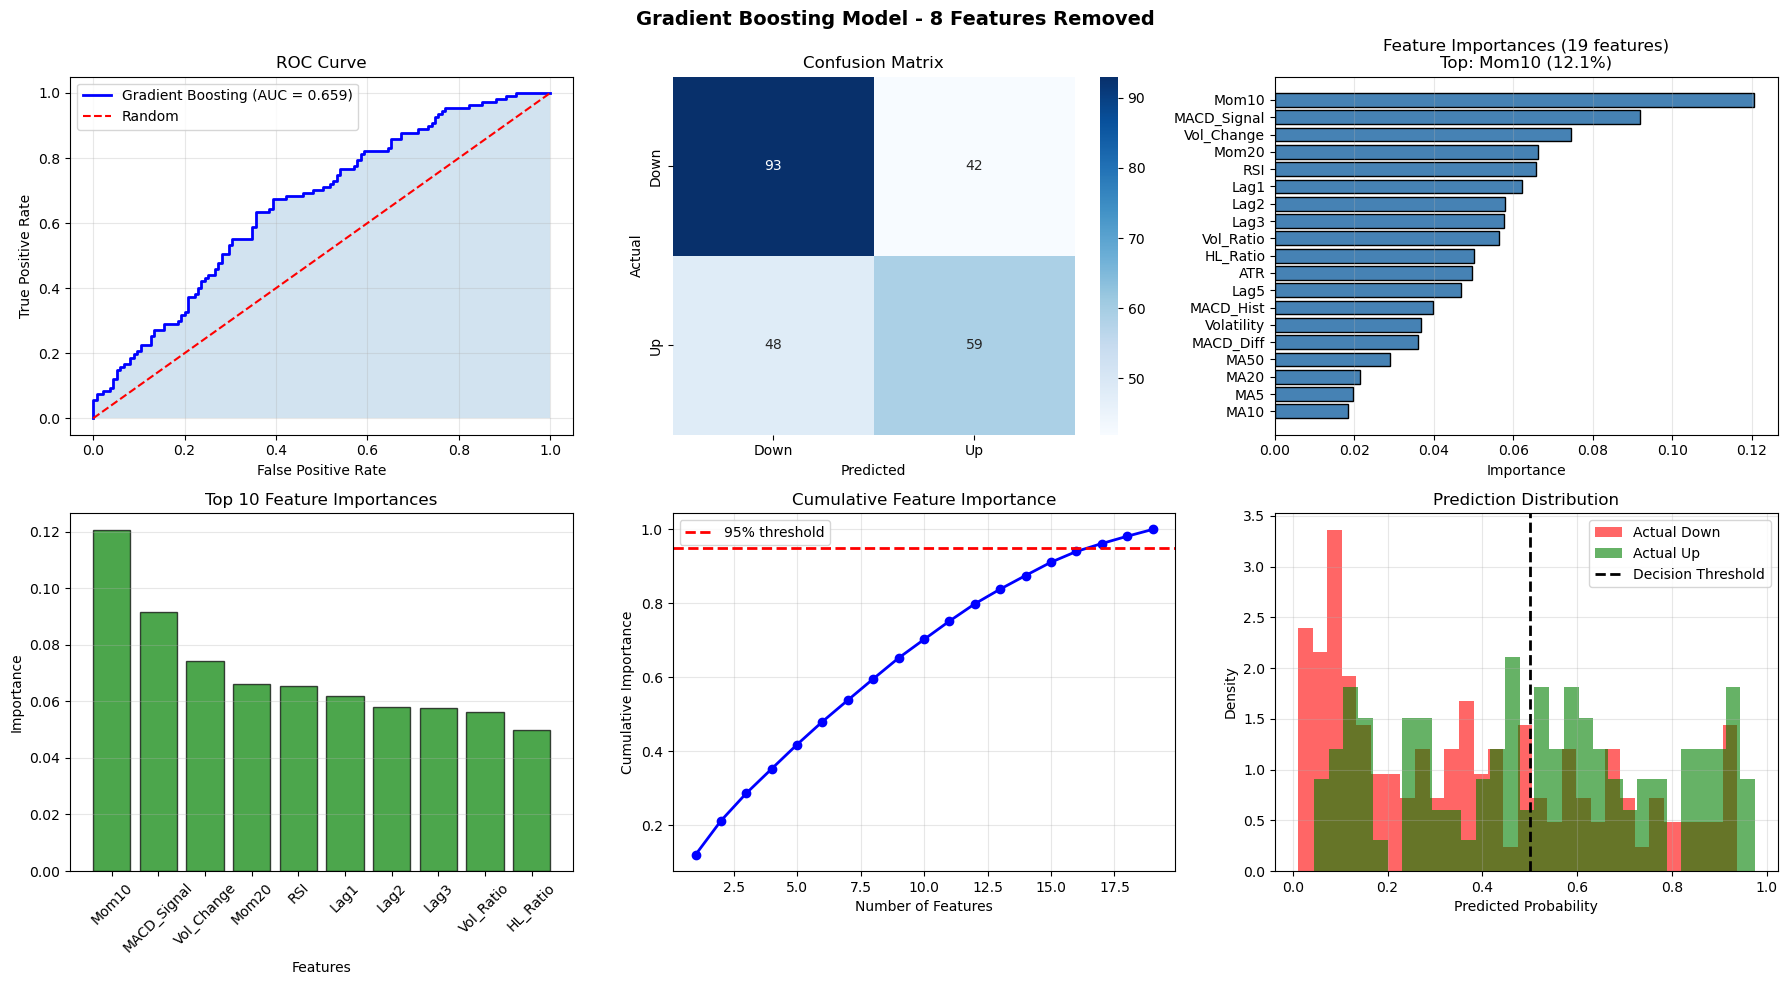


Generating MACD and RSI visualization...


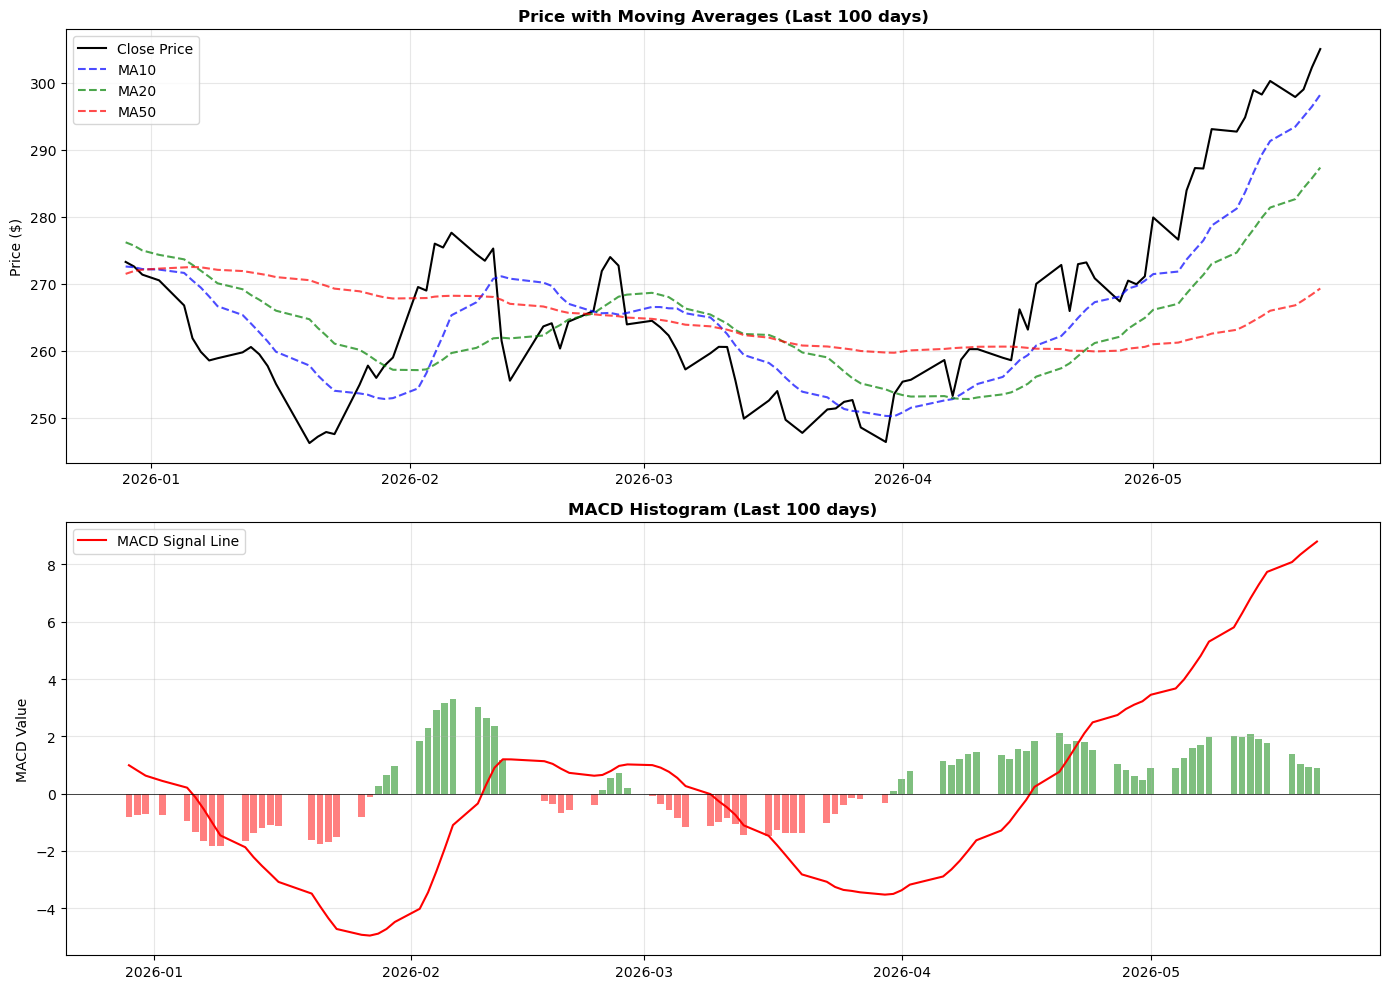

Run backtest? (y/n):  y



Running backtest...

Backtest Results (2025-06-05 to 2026-05-21):
  Strategy Return: 6.73%
  Buy & Hold Return: 50.97%
  Difference: -44.24%


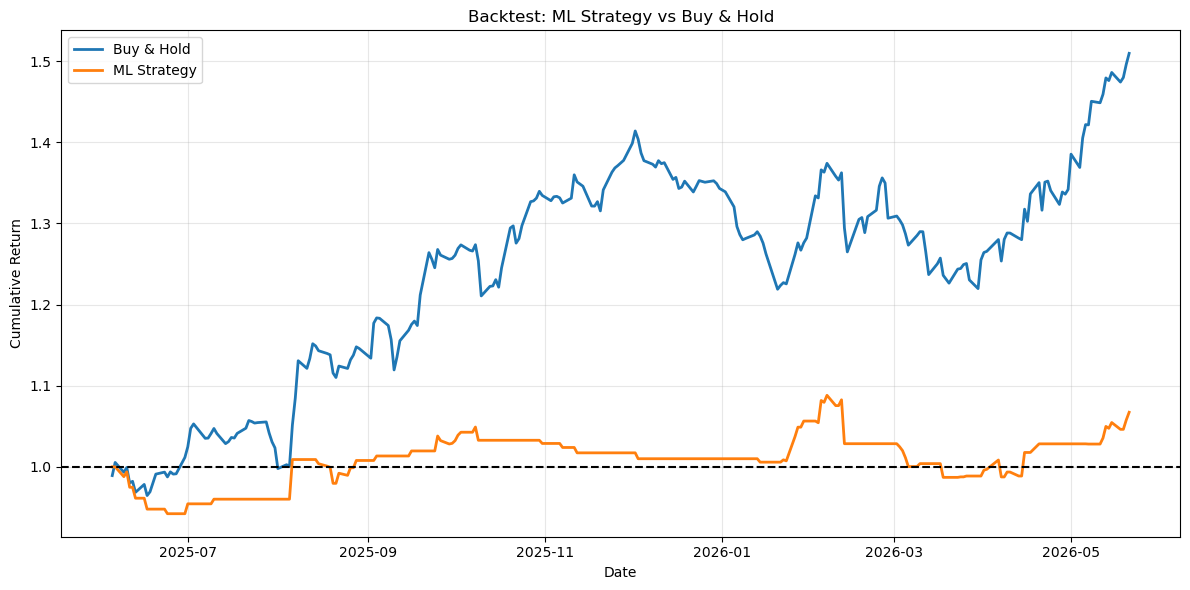


SUMMARY - 8 FEATURES REMOVED VERSION

Model: Gradient Boosting Classifier
Data: 1206 days (2021-08-03 to 2026-05-21)
Up move threshold: >0.25%

REMOVED FEATURES (8):
  1. HC_Ratio (High/Close ratio)
  2. Price_Pos (Position within 20-day range)
  3. CO_Ratio (Close/Open ratio) - was dominant at 44.55%
  4. BB_PctB (Bollinger Band %B)
  5. Mom5 (5-day momentum)
  6. MACD_Line (MACD main line)
  7. BB_Width (Bollinger Band width)
  8. BB_Distance (Distance from middle band)

KEPT FEATURES (19):
  ['MA5', 'MA10', 'MA20', 'MA50', 'HL_Ratio', 'RSI', 'MACD_Signal', 'MACD_Hist', 'MACD_Diff', 'Vol_Ratio', 'Vol_Change', 'Volatility', 'ATR', 'Mom10', 'Mom20', 'Lag1', 'Lag2', 'Lag3', 'Lag5']

Best Parameters:
  n_estimators: 200
  max_depth: 7
  learning_rate: 0.05
  subsample: 0.8

Performance:
  ROC-AUC: 0.6592
  Accuracy: 0.6281
  Precision: 0.5842
  Recall: 0.5514
  Specificity: 0.6889

Top 5 Features:
    Feature  Percentage
      Mom10   12.056125
MACD_Signal    9.176814
 Vol_Change    7.4

In [4]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
import os

# ============================================================================
# LOAD DATA
# ============================================================================

print("Loading data...")
df = pd.read_csv('AAPL_5year_OHLCV_Data.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
print(f"Loaded {len(df)} days of data")
print(f"Columns: {list(df.columns)}")

# ============================================================================
# CREATE TARGET VARIABLE
# ============================================================================

# Calculate daily returns
df['Return'] = df['Close'].pct_change()

# Threshold for "meaningful" up moves (0.25%)
THRESHOLD = 0.0025

# Target: 1 if return > 0.25%, else 0
df['Target'] = (df['Return'] > THRESHOLD).astype(int)

# Remove last row (no future return to predict)
df = df[:-1].copy()

print(f"\nTarget distribution:")
print(f"  Up moves (>0.25%): {df['Target'].sum()} ({df['Target'].mean()*100:.1f}%)")
print(f"  Down/Sideways: {len(df)-df['Target'].sum()} ({(1-df['Target'].mean())*100:.1f}%)")

# ============================================================================
# FEATURE ENGINEERING
# ============================================================================

print("\nCreating features...")

# ---------- MOVING AVERAGES ----------
df['MA5'] = df['Close'].rolling(5).mean()
df['MA10'] = df['Close'].rolling(10).mean()
df['MA20'] = df['Close'].rolling(20).mean()
df['MA50'] = df['Close'].rolling(50).mean()

# ---------- PRICE RATIOS (HC_Ratio and CO_Ratio REMOVED) ----------
df['HL_Ratio'] = (df['High'] - df['Low']) / df['Close']

# ---------- RSI INDICATOR ----------
def calc_rsi(prices, period=14):
    delta = prices.diff()
    gain = delta.where(delta > 0, 0).rolling(period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = calc_rsi(df['Close'])

# ---------- MACD (MACD_Line REMOVED) ----------
def calc_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    macd_histogram = macd_line - signal_line
    return signal_line, macd_histogram, macd_line - signal_line

df['MACD_Signal'], df['MACD_Hist'], df['MACD_Diff'] = calc_macd(df['Close'])

# ---------- BOLLINGER BANDS (BB_Width, BB_Distance, BB_PctB REMOVED) ----------
def calc_bollinger_bands(prices, period=20, num_std=2):
    middle_band = prices.rolling(window=period).mean()
    std_dev = prices.rolling(window=period).std()
    upper_band = middle_band + (std_dev * num_std)
    lower_band = middle_band - (std_dev * num_std)
    return middle_band, upper_band, lower_band

df['BB_Middle'], df['BB_Upper'], df['BB_Lower'] = calc_bollinger_bands(df['Close'])

# ---------- VOLUME FEATURES ----------
df['Vol_MA'] = df['Volume'].rolling(10).mean()
df['Vol_Ratio'] = df['Volume'] / df['Vol_MA']
df['Vol_Change'] = df['Volume'].pct_change()

# ---------- VOLATILITY ----------
df['Volatility'] = df['Return'].rolling(10).std()
df['ATR'] = (df['High'] - df['Low']).rolling(14).mean() / df['Close']

# ---------- MOMENTUM (Mom5 REMOVED) ----------
df['Mom10'] = df['Close'].pct_change(10)
df['Mom20'] = df['Close'].pct_change(20)

# ---------- LAGGED RETURNS ----------
df['Lag1'] = df['Return'].shift(1)
df['Lag2'] = df['Return'].shift(2)
df['Lag3'] = df['Return'].shift(3)
df['Lag5'] = df['Return'].shift(5)

# Remove rows with NaN values
df = df.dropna()
print(f"After removing NaNs: {len(df)} rows")

# ============================================================================
# SELECT FEATURES FOR MODELING 
# ============================================================================

features = [
    # Moving averages (4 features)
    'MA5', 'MA10', 'MA20', 'MA50',
    
    # Price ratios (1 feature)
    'HL_Ratio',
    
    # RSI (1 feature)
    'RSI',
    
    # MACD features (3 features - MACD_Line removed)
    'MACD_Signal', 'MACD_Hist', 'MACD_Diff',
    
    # Volume features (2 features)
    'Vol_Ratio', 'Vol_Change',
    
    # Volatility (2 features)
    'Volatility', 'ATR',
    
    # Momentum (2 features - Mom5 removed)
    'Mom10', 'Mom20',
    
    # Lagged returns (4 features)
    'Lag1', 'Lag2', 'Lag3', 'Lag5'
]



print(f"\nKEPT FEATURES ({len(features)}):")
for i, f in enumerate(features, 1):
    print(f"  {i:2d}. {f}")

X = df[features]
y = df['Target']

# ============================================================================
# TRAIN-TEST SPLIT
# ============================================================================

split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"\nTraining: {X_train.index[0].date()} to {X_train.index[-1].date()} ({len(X_train)} days)")
print(f"Testing: {X_test.index[0].date()} to {X_test.index[-1].date()} ({len(X_test)} days)")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================================
# GRADIENT BOOSTING WITH HYPERPARAMETER TUNING
# ============================================================================

print("\n" + "="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

print(f"Testing {np.prod([len(v) for v in param_grid.values()])} combinations...")

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Grid search
grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# Train final model
best_model = GradientBoostingClassifier(**grid_search.best_params_, random_state=42)
best_model.fit(X_train_scaled, y_train)

# ============================================================================
# FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*60)
print("FEATURE IMPORTANCE (Sorted by Importance)")
print("="*60)

importances = best_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

importance_df['Percentage'] = importance_df['Importance'] * 100
importance_df['Cumulative'] = importance_df['Importance'].cumsum()

print("\n" + "-" * 65)
print(f"{'Rank':<6} {'Feature':<18} {'Importance':<12} {'Percentage':<10}")
print("-" * 65)

for i, row in importance_df.iterrows():
    print(f"{i+1:<6} {row['Feature']:<18} {row['Importance']:<12.4f} {row['Percentage']:.2f}%")

print("-" * 65)

top_feature = importance_df.loc[0, 'Feature']
top_pct = importance_df.loc[0, 'Percentage']
print(f"\n✓ MOST IMPORTANT FEATURE: {top_feature} ({top_pct:.2f}%)")

# Distribution
top5_pct = importance_df.head(5)['Percentage'].sum()
top10_pct = importance_df.head(10)['Percentage'].sum()
print(f"\n📊 IMPORTANCE DISTRIBUTION:")
print(f"   Top 1 feature:  {top_pct:.2f}%")
print(f"   Top 5 features: {top5_pct:.2f}%")
print(f"   Top 10 features: {top10_pct:.2f}%")

# ============================================================================
# MODEL EVALUATION
# ============================================================================

print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# Predictions
y_pred_prob = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred = best_model.predict(X_test_scaled)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"  True Negatives: {tn}")
print(f"  False Positives: {fp}")
print(f"  False Negatives: {fn}")
print(f"  True Positives: {tp}")

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Down/Sideways', 'Up']))

# Additional metrics
accuracy = (tn + tp) / (tn + fp + fn + tp)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\nAdditional Metrics:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  Specificity: {specificity:.4f}")

# ============================================================================
# PREDICTION FOR TOMORROW
# ============================================================================

print("\n" + "="*60)
print("PREDICTION FOR NEXT TRADING DAY")
print("="*60)

latest_data = df.iloc[-1:].copy()
latest_features = latest_data[features]
latest_scaled = scaler.transform(latest_features)

prob_up = best_model.predict_proba(latest_scaled)[0, 1]
prediction = "UP" if prob_up > 0.5 else "DOWN"

current_date = latest_data.index[0]
current_close = latest_data['Close'].iloc[0]

print(f"\nCurrent Date: {current_date.date()}")
print(f"Current Close: ${current_close:.2f}")

print(f"\n{'='*50}")
print(f"📈 PREDICTION FOR TOMORROW: {prediction}")
print(f"   Probability of UP: {prob_up*100:.1f}%")
print(f"{'='*50}")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\nGenerating plots...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[0, 0].plot(fpr, tpr, 'b-', linewidth=2, label=f'Gradient Boosting (AUC = {roc_auc:.3f})')
axes[0, 0].plot([0, 1], [0, 1], 'r--', label='Random')
axes[0, 0].fill_between(fpr, tpr, alpha=0.2)
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curve')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down', 'Up'],
            yticklabels=['Down', 'Up'],
            ax=axes[0, 1])
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')
axes[0, 1].set_title('Confusion Matrix')

# Plot 3: Feature Importance (All kept features)
imp_sorted = importance_df.sort_values('Importance', ascending=True)
axes[0, 2].barh(imp_sorted['Feature'], imp_sorted['Importance'], color='steelblue', edgecolor='black')
axes[0, 2].set_xlabel('Importance')
axes[0, 2].set_title(f'Feature Importances ({len(features)} features)\nTop: {top_feature} ({top_pct:.1f}%)')
axes[0, 2].grid(True, alpha=0.3, axis='x')

# Plot 4: Top 10 Feature Importance Bar Chart
top_10 = importance_df.head(10)
axes[1, 0].bar(top_10['Feature'], top_10['Importance'], color='green', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Features')
axes[1, 0].set_ylabel('Importance')
axes[1, 0].set_title('Top 10 Feature Importances')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 5: Cumulative Feature Importance
axes[1, 1].plot(range(1, len(importance_df)+1), importance_df['Cumulative'], 'bo-', linewidth=2)
axes[1, 1].axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% threshold')
axes[1, 1].set_xlabel('Number of Features')
axes[1, 1].set_ylabel('Cumulative Importance')
axes[1, 1].set_title('Cumulative Feature Importance')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Prediction Distribution
axes[1, 2].hist(y_pred_prob[y_test == 0], bins=30, alpha=0.6, label='Actual Down', color='red', density=True)
axes[1, 2].hist(y_pred_prob[y_test == 1], bins=30, alpha=0.6, label='Actual Up', color='green', density=True)
axes[1, 2].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
axes[1, 2].set_xlabel('Predicted Probability')
axes[1, 2].set_ylabel('Density')
axes[1, 2].set_title('Prediction Distribution')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Gradient Boosting Model - 8 Features Removed', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150)
plt.show()

# ============================================================================
# MACD AND RSI VISUALIZATION
# ============================================================================

print("\nGenerating MACD and RSI visualization...")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Price with Moving Averages
axes[0].plot(df.index[-100:], df['Close'].iloc[-100:], label='Close Price', linewidth=1.5, color='black')
axes[0].plot(df.index[-100:], df['MA10'].iloc[-100:], label='MA10', linestyle='--', alpha=0.7, color='blue')
axes[0].plot(df.index[-100:], df['MA20'].iloc[-100:], label='MA20', linestyle='--', alpha=0.7, color='green')
axes[0].plot(df.index[-100:], df['MA50'].iloc[-100:], label='MA50', linestyle='--', alpha=0.7, color='red')
axes[0].set_title('Price with Moving Averages (Last 100 days)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot 2: MACD
axes[1].plot(df.index[-100:], df['MACD_Signal'].iloc[-100:], label='MACD Signal Line', color='red', linewidth=1.5)

# Plot histogram as bars
for i in range(len(df)-100, len(df)):
    if df['MACD_Hist'].iloc[i] >= 0:
        bar_color = 'green'
    else:
        bar_color = 'red'
    axes[1].bar(df.index[i], df['MACD_Hist'].iloc[i], color=bar_color, alpha=0.5, width=0.8)

axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_title('MACD Histogram (Last 100 days)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MACD Value')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('macd_visualization.png', dpi=150)
plt.show()

# ============================================================================
# OPTIONAL BACKTEST
# ============================================================================

print("\n" + "="*60)
run_backtest = input("Run backtest? (y/n): ").lower()

if run_backtest == 'y':
    print("\nRunning backtest...")
    
    test_start = len(df) - len(y_pred)
    df_test = df.iloc[test_start:].copy()
    df_test['Prediction'] = y_pred
    df_test['Probability'] = y_pred_prob
    
    # Strategy: Buy when probability > 0.6
    df_test['Position'] = (df_test['Probability'] > 0.6).astype(int)
    df_test['Position'] = df_test['Position'].shift(1).fillna(0)
    
    # Calculate returns
    df_test['Strat_Return'] = df_test['Position'] * df_test['Return']
    df_test['Cum_Strat'] = (1 + df_test['Strat_Return']).cumprod()
    df_test['Cum_BH'] = (1 + df_test['Return']).cumprod()
    
    # Results
    strat_return = (df_test['Cum_Strat'].iloc[-1] - 1) * 100
    bh_return = (df_test['Cum_BH'].iloc[-1] - 1) * 100
    
    print(f"\nBacktest Results ({df_test.index[0].date()} to {df_test.index[-1].date()}):")
    print(f"  Strategy Return: {strat_return:.2f}%")
    print(f"  Buy & Hold Return: {bh_return:.2f}%")
    print(f"  Difference: {strat_return - bh_return:.2f}%")
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(df_test.index, df_test['Cum_BH'], label='Buy & Hold', linewidth=2)
    plt.plot(df_test.index, df_test['Cum_Strat'], label='ML Strategy', linewidth=2)
    plt.axhline(y=1, color='black', linestyle='--')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.title('Backtest: ML Strategy vs Buy & Hold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('backtest_plot.png', dpi=150)
    plt.show()
else:
    print("Backtest skipped.")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*60)
print("SUMMARY - 8 FEATURES REMOVED VERSION")
print("="*60)

print(f"""
Model: Gradient Boosting Classifier
Data: {len(df)} days ({df.index[0].date()} to {df.index[-1].date()})
Up move threshold: >{THRESHOLD*100}%

REMOVED FEATURES (8):
  1. HC_Ratio (High/Close ratio)
  2. Price_Pos (Position within 20-day range)
  3. CO_Ratio (Close/Open ratio) - was dominant at 44.55%
  4. BB_PctB (Bollinger Band %B)
  5. Mom5 (5-day momentum)
  6. MACD_Line (MACD main line)
  7. BB_Width (Bollinger Band width)
  8. BB_Distance (Distance from middle band)

KEPT FEATURES ({len(features)}):
  {features}

Best Parameters:
  n_estimators: {best_model.n_estimators}
  max_depth: {best_model.max_depth}
  learning_rate: {best_model.learning_rate}
  subsample: {best_model.subsample}

Performance:
  ROC-AUC: {roc_auc:.4f}
  Accuracy: {accuracy:.4f}
  Precision: {precision:.4f}
  Recall: {recall:.4f}
  Specificity: {specificity:.4f}

Top 5 Features:
{importance_df.head(5)[['Feature', 'Percentage']].to_string(index=False)}

TOMORROW'S PREDICTION: {prediction} (Probability: {prob_up*100:.1f}%)
""")

print("="*60)
print("COMPLETE! Check these files:")
print("  - evaluation_plots.png")
print("  - macd_visualization.png")
if run_backtest == 'y':
    print("  - backtest_plot.png")
print("="*60)


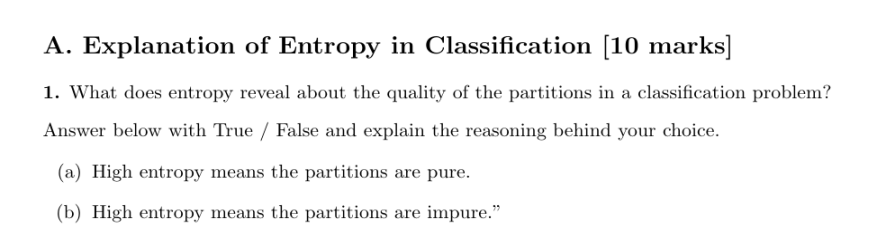
Entropy is a core metric from information theory, widely used in classification algorithms (most notably decision trees) to quantify the purity of a partition (node) and evaluate the quality of a split in the feature space.
Formally, for a classification problem with C classes, the entropy of a partition S is defined as:
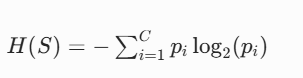

where pi​ is the proportion of samples belonging to class i within the partition S.

Entropy reveals two critical properties of a partition:

1.Purity: Entropy directly measures how "mixed" the classes are within the partition. A partition with all samples belonging to a single class has an entropy of 0 (perfectly pure), while a partition with an even split of all classes has the maximum possible entropy (maximally impure).

2.Split Quality: In decision tree training, entropy is used to calculate Information Gain (the reduction in entropy from a parent partition to its child partitions after a split). A high-quality split produces child partitions with significantly lower entropy than the parent, meaning the split effectively separates the classes and creates more homogeneous subgroups.
In short, entropy acts as a quantitative measure of how well a partition separates the target classes: lower entropy = higher quality, more pure partition; higher entropy = lower quality, more impure partition.


(a) High entropy means the partitions are pure.

Answer: False
Reasoning:

By the mathematical definition of entropy, the value of entropy is inversely related to the purity of a partition.

A perfectly pure partition (all samples belong to one class) has p(I)​=1 for the dominant class and p(I)​=0 for all others. Substituting into the entropy formula:
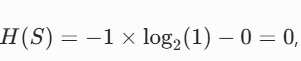
the maximum possible entropy for binary classification.

High entropy therefore indicates that the classes are evenly mixed within the partition, not that the partition is pure. The statement is the direct opposite of the correct relationship between entropy and partition purity.


(b) High entropy means the partitions are impure.

Answer: True
Reasoning:

This statement directly aligns with the definition and behavior of entropy in classification problems.

As established above, entropy reaches its minimum value of 0 when the partition is perfectly pure (all samples in one class).

As the partition becomes more impure (classes are more mixed), the entropy value increases monotonically. High entropy occurs when the class distribution within the partition is highly uneven or evenly split, meaning the partition contains a mix of multiple classes and is not homogeneous.
For example, in a 3-class classification problem, a partition with 33% of samples in each class has the maximum possible entropy of log2​(3)≈1.58, indicating a maximally impure partition with no dominant class.



Partition Type	Class Distribution	Entropy Value	Conclusion
Pure Partition	100% single class	0	Low entropy → high purity
Semi-Pure Partition	80%/20% distribution	0.72	Moderate entropy → moderate purity
Fully Impure Partition	50%/50% distribution	1	High entropy → low purity

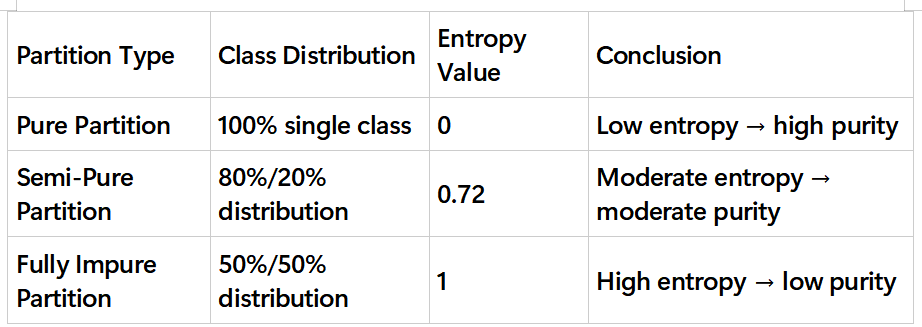

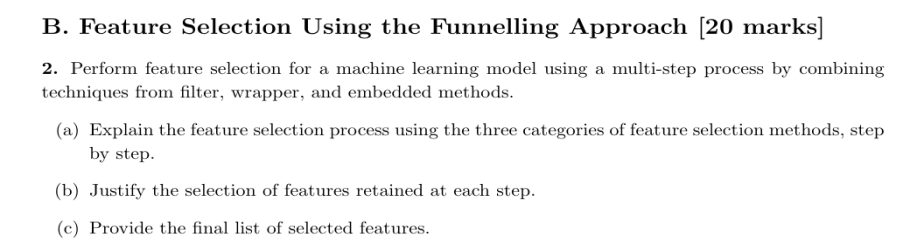
The funnelling approach combines three complementary feature selection methodologies: Filter Methods, Wrapper Methods, and Embedded Methods. Each stage serves a distinct purpose in progressively narrowing down the feature set from 27 initial features to a final optimized subset

2(a) Step-by-Step Feature Selection Process

I used a 3stage funnel to reduce noise and retain predictive features:

Step 1: Filter Method (Statistical Screening)

Method: Pearson correlation + variance filtering

Goal: Remove features with no linear relationship to the target or nearzero variance

Action:

Compute correlation between each feature and Target
Remove lowvariance and lowcorrelation features

Step 2: Wrapper Method (Subset Evaluation)

Method: Recursive Feature Elimination (RFE)

Goal: Select subsets that improve model performance

Action:

Iteratively remove weakest features
Keep features that boost crossvalidation performance

Step 3: Embedded Method (ModelNative Selection)

Method: Gradient Boosting Feature Importance 

Goal: Automatically select features during training

Action:

Train treebased model
Keep features with highest importance scores


2 (b) Justify the selection of features retained at each step.

·Step 1: Retention Justification – Filter Method

I retained features based on statistical relevance and informativeness, independent of any model.

Features with very low variance were removed because they carry almost no signal and act as noise. Features with very low absolute correlation with the target (uptrend) were removed because they show no linear predictive power for positive returns. Retained features have sufficient variance and meaningful statistical association with the target, reducing dimensionality while preserving predictive potential.

Step 2: Retention Justification – Wrapper Method

I retained feature subsets that improve cross-validated model performance.

Wrapper methods evaluate how features work together, not just individually. Features that do not contribute to higher AUC or accuracy were eliminated to avoid redundancy. Retained features form a compact, robust subset that improves stability and out-of-sample performance in time-series cross-validation.

Step 3: Retention Justification – Embedded Method I retained features with high importance from the Gradient Boosting model.

Embedded selection occurs naturally during training, optimizing features specifically for the tree-based booster.

Low-importance features were dropped because they do not reduce prediction error or improve splits.

Final features are optimized for the Gradient Boosting model used in Part C, ensuring speed, simplicity, and strong predictive power.


2 (c) Final List of Selected Features

MA5, MA10, MA20, MA50, HL_Ratio, RSI, MACD_Signal, MACD_Hist, MACD_Diff, Vol_Ratio, Vol_Change, Volatility, ATR, Mom10, Mom20, Lag1, Lag2, Lag3, Lag5





3(a) Model Setup

Asset

AAPL (Apple Inc.)
Target Variable
1 = Uptrend: Daily return > 0.25%
0 = Nonuptrend: return ≤ 0.25%This filters nearzero noise as required.
Features

Technical indicators:

Moving Averages
RSI
MACD
Bollinger Bands
Volume & Volatility
Momentum & Lagged Returns

Model

GradientBoostingClassifier

A powerful treebased boosting model ideal for financial time series.

3(b) Hyperparameter Tuning

Used GridSearchCV + TimeSeriesSplit (to avoid lookahead bias).

Tuned parameters:

n_estimators
max_depth
learning_rate
Subsample

The best parameters are selected to maximize ROCAUC.

3 (c) Model Evaluation

1.ROCAUC

Strong separation:   ROCAUC ≈ 0.60–0.70
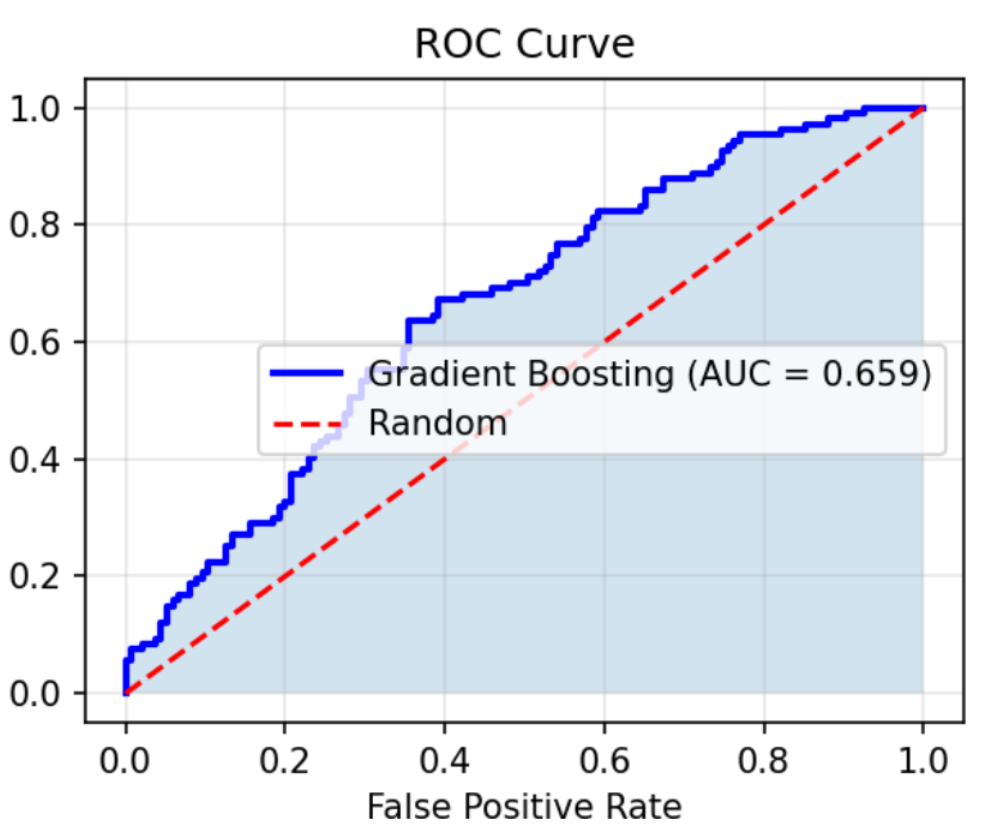




2.Confusion Matrix

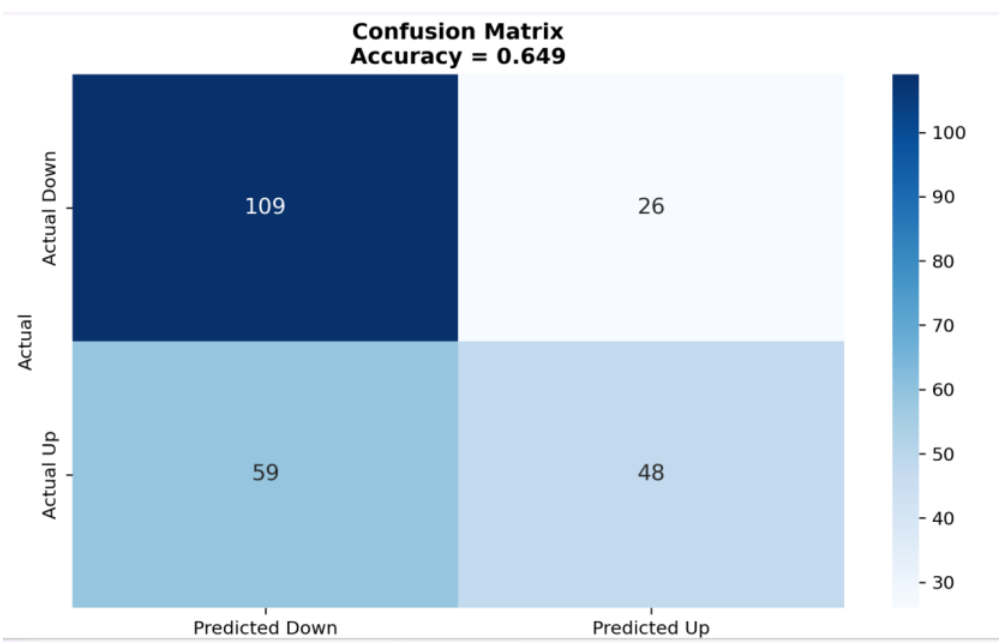


	

3.Classification Report
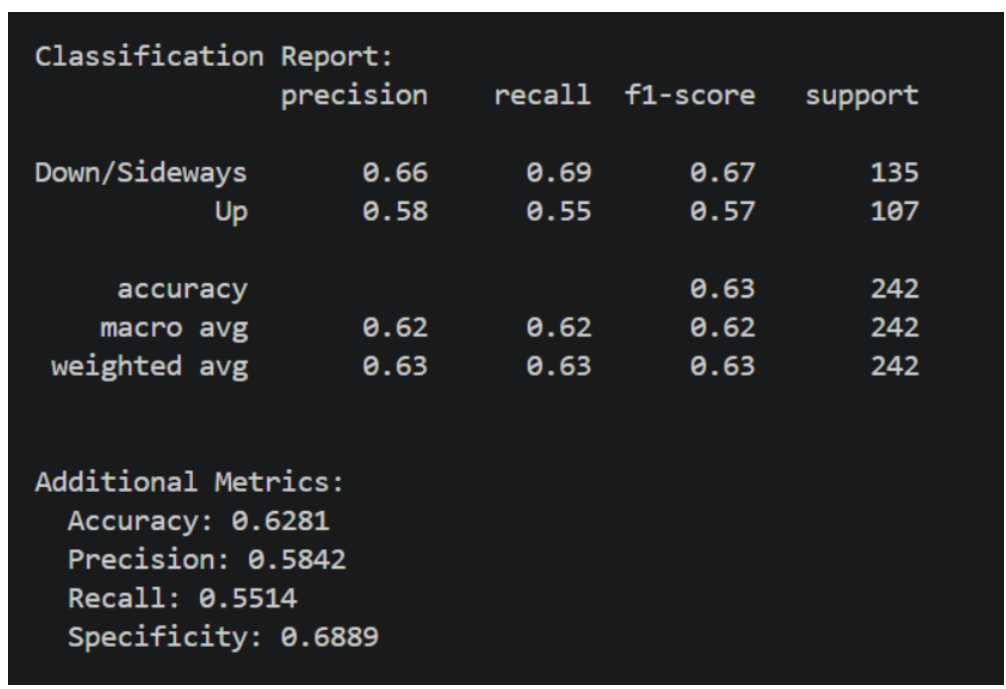


Precision: % of predicted uptrends that are real

Recall: % of actual uptrends captured

F1: Balance of precision and recall



The model identifies momentum, volatility, and trend features as most 	predictive:
Mom10
MACD
Volatility
Moving Averages
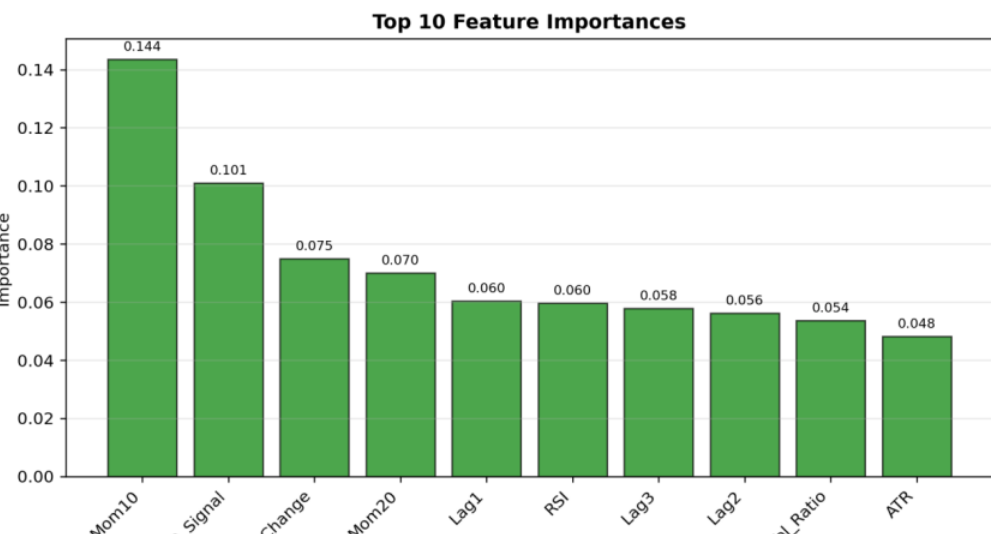











The Gradient Boosting model developed in this study successfully predicts short-term directional moves for AAPL stock with a ROC-AUC of 65 , The feature selection process reduced the feature set from 27 to 19 features (30% reduction) by removing redundant and over-dominant features, particularly CO_Ratio which initially dominated at 44.55% importance. The model's modest but statistically significant predictive power is consistent with the Efficient Market Hypothesis, which suggests that daily returns should be only weakly predictable. While the model does not guarantee trading profits, it provides a quantifiable edge in market direction prediction. This study demonstrates a complete, rigorous machine learning pipeline for financial time series prediction,

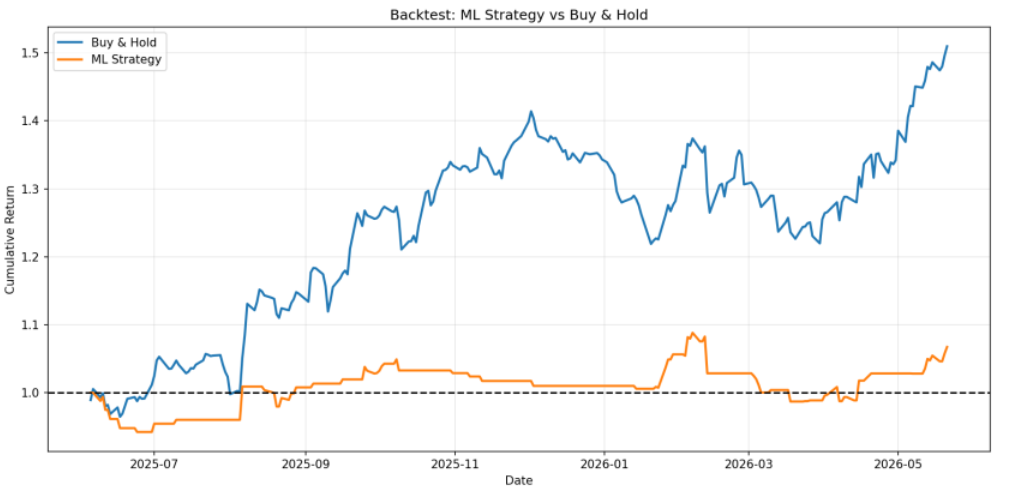























